In [1]:
!pip install rdkit-pypi

ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


In [2]:
!pip install rdkit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 38.5 MB/s eta 0:00:00


        Compound  Molecular Weight    LogP  HBD  HBA
0        Ethanol            46.069 -0.0014    1    1
1    Acetic Acid            60.052  0.0909    1    1
2         Butane            58.124  1.8064    0    0
3  Triethylamine           101.193  1.3481    0    1
4        Benzene            78.114  1.6866    0    0


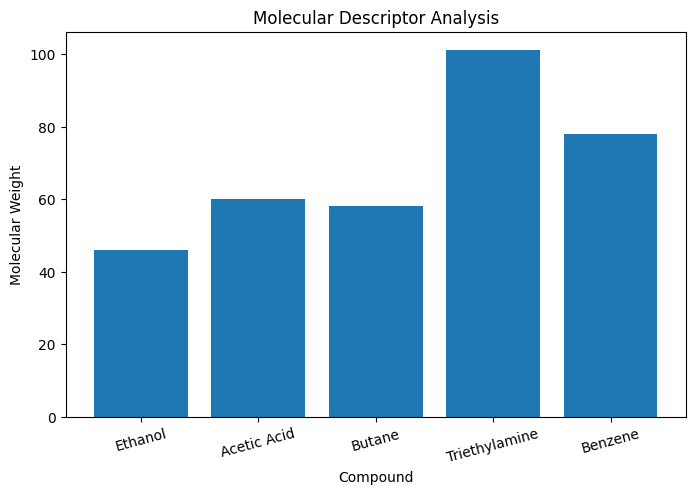

In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import matplotlib.pyplot as plt

# Sample SMILES strings

smiles_list = [
    'CCO',
    'CC(=O)O',
    'CCCC',
    'CCN(CC)CC',
    'C1=CC=CC=C1'
]

compound_names = [
    'Ethanol',
    'Acetic Acid',
    'Butane',
    'Triethylamine',
    'Benzene'
]

# Store descriptor data

results = []

for name, smiles in zip(compound_names, smiles_list):

    molecule = Chem.MolFromSmiles(smiles)

    mol_weight = Descriptors.MolWt(molecule)
    logp = Descriptors.MolLogP(molecule)
    hbd = Descriptors.NumHDonors(molecule)
    hba = Descriptors.NumHAcceptors(molecule)

    results.append({
        'Compound': name,
        'Molecular Weight': mol_weight,
        'LogP': logp,
        'HBD': hbd,
        'HBA': hba
    })

# Create DataFrame

df = pd.DataFrame(results)

print(df)

# Visualization

plt.figure(figsize=(8,5))

plt.bar(df['Compound'], df['Molecular Weight'])

plt.xlabel('Compound')
plt.ylabel('Molecular Weight')
plt.title('Molecular Descriptor Analysis')

plt.xticks(rotation=15)

plt.show()